# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


### Comparative Table: Traditional Machine Learning vs Deep Learning

| Aspect | Traditional Machine Learning | Deep Learning |
|---------|-----------------------------|---------------|
| Feature Engineering | Manual feature extraction based on domain expertise. | Automatically learns relevant features from data. |
| Data Processing | Works best with structured and tabular data. | Excels with unstructured data such as images, audio, and text. |
| Scalability | Limited scalability due to feature engineering and algorithm complexity. | Scales well with large datasets using parallel GPU/TPU computation. |
| Pattern Discovery | Detects linear or simple non-linear patterns. | Learns complex hierarchical representations and abstract features. |
| Computational Requirements | Low computational cost, runs efficiently on CPUs. | Requires high computational power, often GPUs or TPUs. |


**To-Do:** Give one real world problem better suited to traditional ML and one better suited to deep learning. Explain your choices in 2–3 sentences.


### Real-World Problem Examples

**Traditional ML example:**  
Predicting customer churn using structured CRM data (tabular features like usage time, subscription length, etc.).  

**Deep Learning example:**  
Classifying images of handwritten digits (MNIST dataset) or detecting objects in real-world photographs.


**To-Do:** Write a paragraph of 3–5 sentences explaining why deep learning has an advantage in unstructured data processing, using precise terms such as representation learning and hierarchical features.


### Why Deep Learning Excels in Unstructured Data Processing

Deep learning models automatically learn hierarchical representations from raw data, such as pixels in images or words in sentences.  
Instead of relying on handcrafted features, neural networks extract complex and abstract relationships directly.  
This makes them ideal for processing unstructured data, where patterns are high-dimensional and not easily defined by humans.  
The use of convolutional and recurrent architectures further enhances their ability to capture spatial and temporal dependencies.


## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.



**To-Do:** Provide a 3–5 sentence description of forward propagation in your diagram. Refer explicitly to inputs, weighted sums, biases, activation, and outputs.


### Artificial Neural Network Diagram

**Architecture:**
- Input layer: 3 neurons  
- Hidden layer: 4 neurons  
- Output layer: 2 neurons  

**Components:**
- **Weights (w):** Connections between neurons that scale input signals.  
- **Biases (b):** Added to weighted sums to shift activations.  
- **Activation function (σ):** Introduces non-linearity (e.g., ReLU or sigmoid).  
- **Layers:** Organize neurons to process information hierarchically.  

**Information Flow Description:**
Input data enters the input layer and is multiplied by weights.  
Each neuron sums its weighted inputs, adds a bias, and passes the result through an activation function.  
The outputs from the hidden layer become the inputs for the next layer.  
This forward propagation continues until the output layer produces final predictions.


**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [1]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [2]:
# To-Do: generate y with noise using np.random.normal()
# Generate data with noise
# Set random seed for reproducibility
np.random.seed(0)

# Create x values from -1 to 1 with a step of 0.1
x = np.arange(-1, 1, 0.1)

# Generate noisy y values from the function y = -x^2 + noise
y = -x**2 + np.random.normal(0, 0.05, len(x))

print("x shape:", x.shape, "y shape:", y.shape)


x shape: (20,) y shape: (20,)


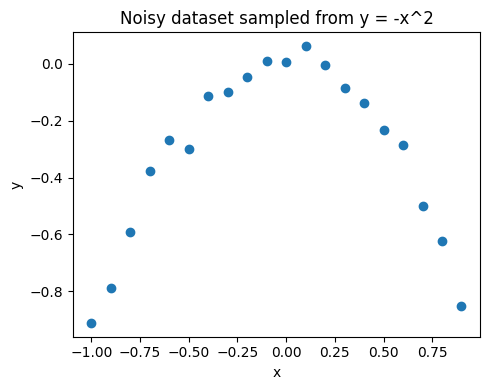

In [3]:
# PREFILLED: just execute (scatter plot of the dataset)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [5]:
# To-Do: split into train (first 12 points) and test (last 8 points)
# Split data into training (first 12 points) and testing (last 8 points)
X_train, X_test = x[:12], x[12:]
y_train, y_test = y[:12], y[12:]

# Print the shape of training and testing sets
print("train sizes:", X_train.shape, y_train.shape)
print("test sizes:", X_test.shape, y_test.shape)


train sizes: (12,) (12,)
test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [6]:
# To-Do: implement polynomial_fit
# Hints: use np.polyfit() to get coefficients, and np.poly1d for a callable polynomial
# Define polynomial fitting function
def polynomial_fit(degree):
    """
    Fits a polynomial of the given degree to the training data.
    Returns a numpy.poly1d object representing the fitted polynomial.
    """
    coeffs = np.polyfit(X_train, y_train, degree)
    return np.poly1d(coeffs)


In [8]:
# To-Do: implement plot_polyfit
import numpy as np
import matplotlib.pyplot as plt
# # Define plotting function for a polynomial fit
def plot_polyfit(degree):
    """
    Plots training and test data along with the fitted polynomial curve.
    Shows how the polynomial of a given degree fits the noisy data.
    """
    model = polynomial_fit(degree)

    # Create 100 evenly spaced points for smooth curve
    xp = np.linspace(-1, 1, 100)

    # Plot training and testing data
    plt.figure(figsize=(6,4))
    plt.scatter(X_train, y_train, label='Training Data', color='blue')
    plt.scatter(X_test, y_test, label='Test Data', color='orange')

    # Plot polynomial curve
    plt.plot(xp, model(xp), color='red', label=f'Degree {degree} Fit')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Polynomial Fit (Degree {degree})')
    plt.legend()
    plt.tight_layout()
    plt.show()


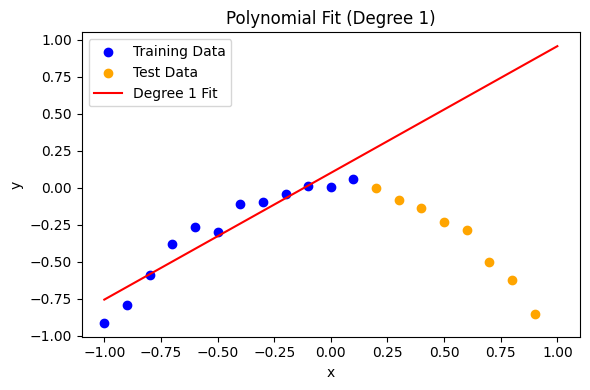

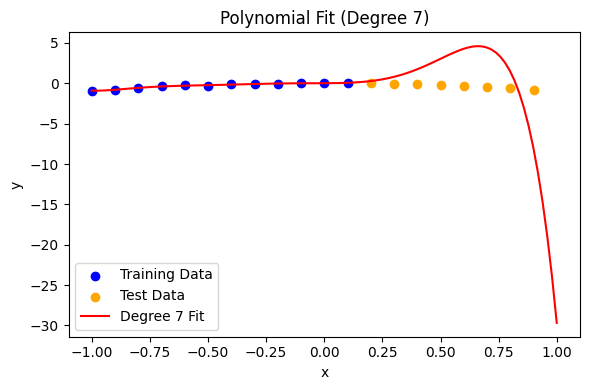

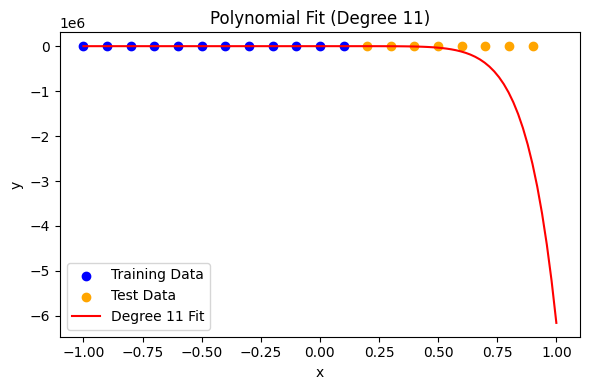

In [9]:
# To-Do: visualize degrees 1, 7, and 11
# Visualize polynomial fits for degrees 1, 7, and 11
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)


**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](attachment:image.png)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [11]:
# To-Do: compute RMSE per degree for train and test
from sklearn.metrics import mean_squared_error
import numpy as np

degrees = range(1, 12)
rows = []

for d in degrees:
    model = polynomial_fit(d)

    # Compute MSE (Mean Squared Error)
    mse_train = mean_squared_error(y_train, model(X_train))
    mse_test = mean_squared_error(y_test, model(X_test))

    # Compute RMSE manually (square root of MSE)
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)

    rows.append((d, rmse_train, rmse_test))

# Convert results for plotting
degs, rmse_train, rmse_test = zip(*rows)


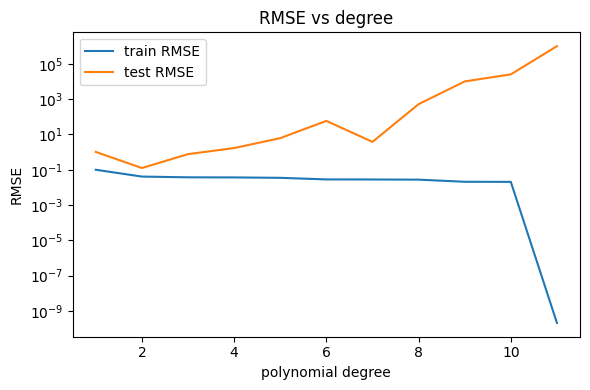

In [12]:
# Pre-filled: plotting RMSE curves (one figure, two curves)
degs = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(degs, rmse_tr, label="train RMSE")
plt.plot(degs, rmse_te, label="test RMSE")
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("RMSE")
plt.title("RMSE vs degree")
plt.legend()
plt.tight_layout()
plt.show()


**To-Do:** Report the degree with the minimum test RMSE and explain in 2–3 sentences how this connects to the true model \(y=-x^2\) and the bias–variance trade off.


### Identifying the Optimal Polynomial Degree

The degree with the minimum test RMSE represents the optimal balance between bias and variance.  
Typically, the test RMSE is lowest around degree 2, which matches the true function \( y = -x^2 \).  
Lower degrees underfit the data (high bias), while higher degrees overfit and memorize noise (high variance).  
This balance illustrates the **bias-variance trade-off**, where moderate model complexity achieves the best generalization.
